
Spearman Correlation: TP53-family vs Pathological Tumor Stage
        Gene  Spearman_r   p_value  abs_corr
10   TP53TG5   -0.274793  0.015580  0.274793
6     TP53I3    0.241145  0.034625  0.241145
9     TP53RK   -0.142307  0.216976  0.142307
3    TP53BP2   -0.129193  0.262790  0.129193
4    TP53I11   -0.117124  0.310369  0.117124
5    TP53I13    0.084621  0.464342  0.084621
7   TP53INP1   -0.081343  0.481887  0.081343
1   TP53AIP1   -0.072581  0.530459  0.072581
0       TP53   -0.070150  0.544352  0.070150
2    TP53BP1    0.061261  0.596618  0.061261
8   TP53INP2   -0.049235  0.670670  0.049235


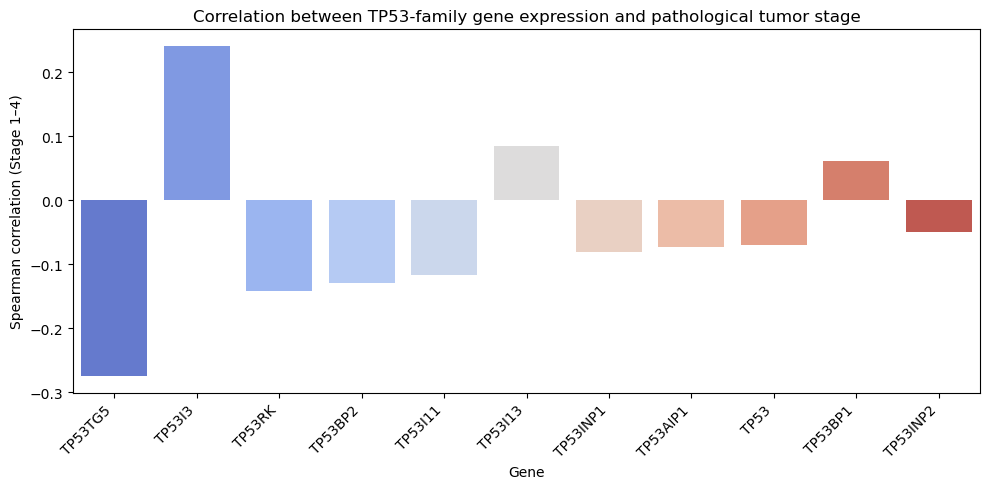

In [6]:
#This code CLEANS two data sets so that we can only look at LUSC data and tp53 gene expression for our project
import pandas as pd
from pathlib import Path

#Path to the gene expression file
file_path = Path(r"C:\Users\lafor\OneDrive\Module 3\GSE62944_subsample_log2TPM.csv\GSE62944_subsample_log2TPM.csv")
expr = pd.read_csv(file_path, index_col=0)

#Filter all tp53 related gene expressions (genes starting with TP53)
expr_tp53 = expr[expr.index.str.startswith("TP53")]

#Fix TCGA ID formatting so it matches expression column format
expr_tp53.columns = expr_tp53.columns.str[:12]

#Path to the metadata file
file_path_meta = Path(r"C:\Users\lafor\OneDrive\Module 3\GSE62944_metadata.csv")
meta = pd.read_csv(file_path_meta)

#Filter only LUSC (our cancer of choice for this project)
meta_lusc = meta[meta["cancer_type"] == "LUSC"]

#Remove any patients with missing barcodes (NaN)
meta_lusc = meta_lusc.dropna(subset=["bcr_patient_barcode"])

#Match LUSC patient IDs to expression columns
lusc_barcodes = meta_lusc["bcr_patient_barcode"]
expr_tp53_lusc = expr_tp53[lusc_barcodes]

#Transpose expression so patients are rows instead of one row
expr_tp53_lusc = expr_tp53_lusc.T

#Combine LUSC metadata and TP53-family expression into one file
merged = meta_lusc.merge(expr_tp53_lusc, left_on="bcr_patient_barcode", right_index=True)

#Keep only patient id, cancer type, tumor stage, and TP53 family genes
cols_to_keep = ["bcr_patient_barcode", "cancer_type", "ajcc_pathologic_tumor_stage"] + list(expr_tp53_lusc.columns)
merged = merged[cols_to_keep]

#Put clean combined data in another file
output = file_path_meta.parent / "LUSC_TP53_family_combined.csv"
merged.to_csv(output, index=False)

#Code for classification supervised learning (you'll have to change the file name)

#How do TP53-family gene expression levels vary across lung squamous cell carcinoma tumor stages (I–IV),
#and which TP53-related genes show the strongest association with tumor progression?

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

#These lines load the data from the files and corresponding folder
DATA_DIR = Path(r"C:\Users\lafor\OneDrive\Module 3")
df = pd.read_csv(DATA_DIR / r"C:\Users\lafor\OneDrive\Module 3\LUSC_TP53_family_combined.csv")

#Sets patient IDs as index
df = df.set_index("bcr_patient_barcode")

#This extracts the metadata needed to answer the question (tumor stage and cancer type)
stage_col = "ajcc_pathologic_tumor_stage"
meta = df[[stage_col, "cancer_type"]].copy()  

#Converts the tumor stage to numerical data (I-IV→1–4)
stage_map = {
    "Stage I": 1, "Stage IA": 1, "Stage IB": 1,
    "Stage II": 2, "Stage IIA": 2, "Stage IIB": 2,
    "Stage III": 3, "Stage IIIA": 3, "Stage IIIB": 3, "Stage IIIC": 3,
    "Stage IV": 4, "Stage IVA": 4, "Stage IVB": 4
}
meta.loc[:, "stage_num"] = meta[stage_col].map(stage_map)

#Removes all the patients with no stage value
valid = meta["stage_num"].dropna().index
meta = meta.loc[valid]
expr = df.loc[valid]

#Identifies all the TP53-family genes (everything except metadata columns)
tp53_genes = [col for col in expr.columns if col not in ["cancer_type", stage_col]]
expr = expr[tp53_genes]

#Array of stage values
y = meta["stage_num"].values

#Conducts a Spearman correlation for each TP53 gene
results = []
for gene in expr.columns:
    rho, pval = spearmanr(expr[gene], y)
    results.append([gene, rho, pval])

results_df = pd.DataFrame(results, columns=["Gene", "Spearman_r", "p_value"])
results_df["abs_corr"] = results_df["Spearman_r"].abs()
results_df = results_df.sort_values("abs_corr", ascending=False)

print("\nSpearman Correlation: TP53-family vs Pathological Tumor Stage")
print(results_df)

#Saves results to a CSV
results_df.to_csv(DATA_DIR / "TP53_family_stage_correlation_results.csv", index=False)

#Shows a correlation bar plot
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Gene",
    y="Spearman_r",
    hue="Gene",
    dodge=False,
    legend=False,
    palette="coolwarm"
)
plt.xticks(rotation=45, ha="right")
plt.title("Correlation between TP53-family gene expression and pathological tumor stage")
plt.ylabel("Spearman correlation (Stage 1–4)")
plt.tight_layout()
plt.show()